# E_commarce customer segmentation system

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("smartcart_customers.csv")
df.isnull().sum()


ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Step 1 ( Data Preprocessing )

In [3]:
df["Income"]=df["Income"].fillna(df["Income"].median())


# Feature Engineering

In [4]:
# Customer Age
df["Age"]=2026-df["Year_Birth"]


In [5]:
# Customer Joining Date
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date=df["Dt_Customer"].max()
df["Customer Tenure Days"]=(reference_date-df["Dt_Customer"]).dt.days


In [6]:
# Spending
df["Total Spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]
# Total Children
df["Total_Children"]=df["Kidhome"]+df["Teenhome"]

In [7]:
# Education
df["Education"]=df["Education"].replace({
    "2n Cycle":"Undergraduate","Basic":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate","PhD":"Postgraduate"
})


In [8]:
# Maritial Status
df["Living_With"]=df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone","Divorced":"Alone",
    "Widow":"Alone","Absurd":"Alone","YOLO":"Alone"
})


In [9]:
 df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer Tenure Days', 'Total Spending',
       'Total_Children', 'Living_With'],
      dtype='object')

In [10]:
# Dropping Unwanted columns
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntGoldProds","MntSweetProducts"]
col_to_drop=cols+spending_cols
df_cleaned=df.drop(columns=col_to_drop)


# Remove Outliers

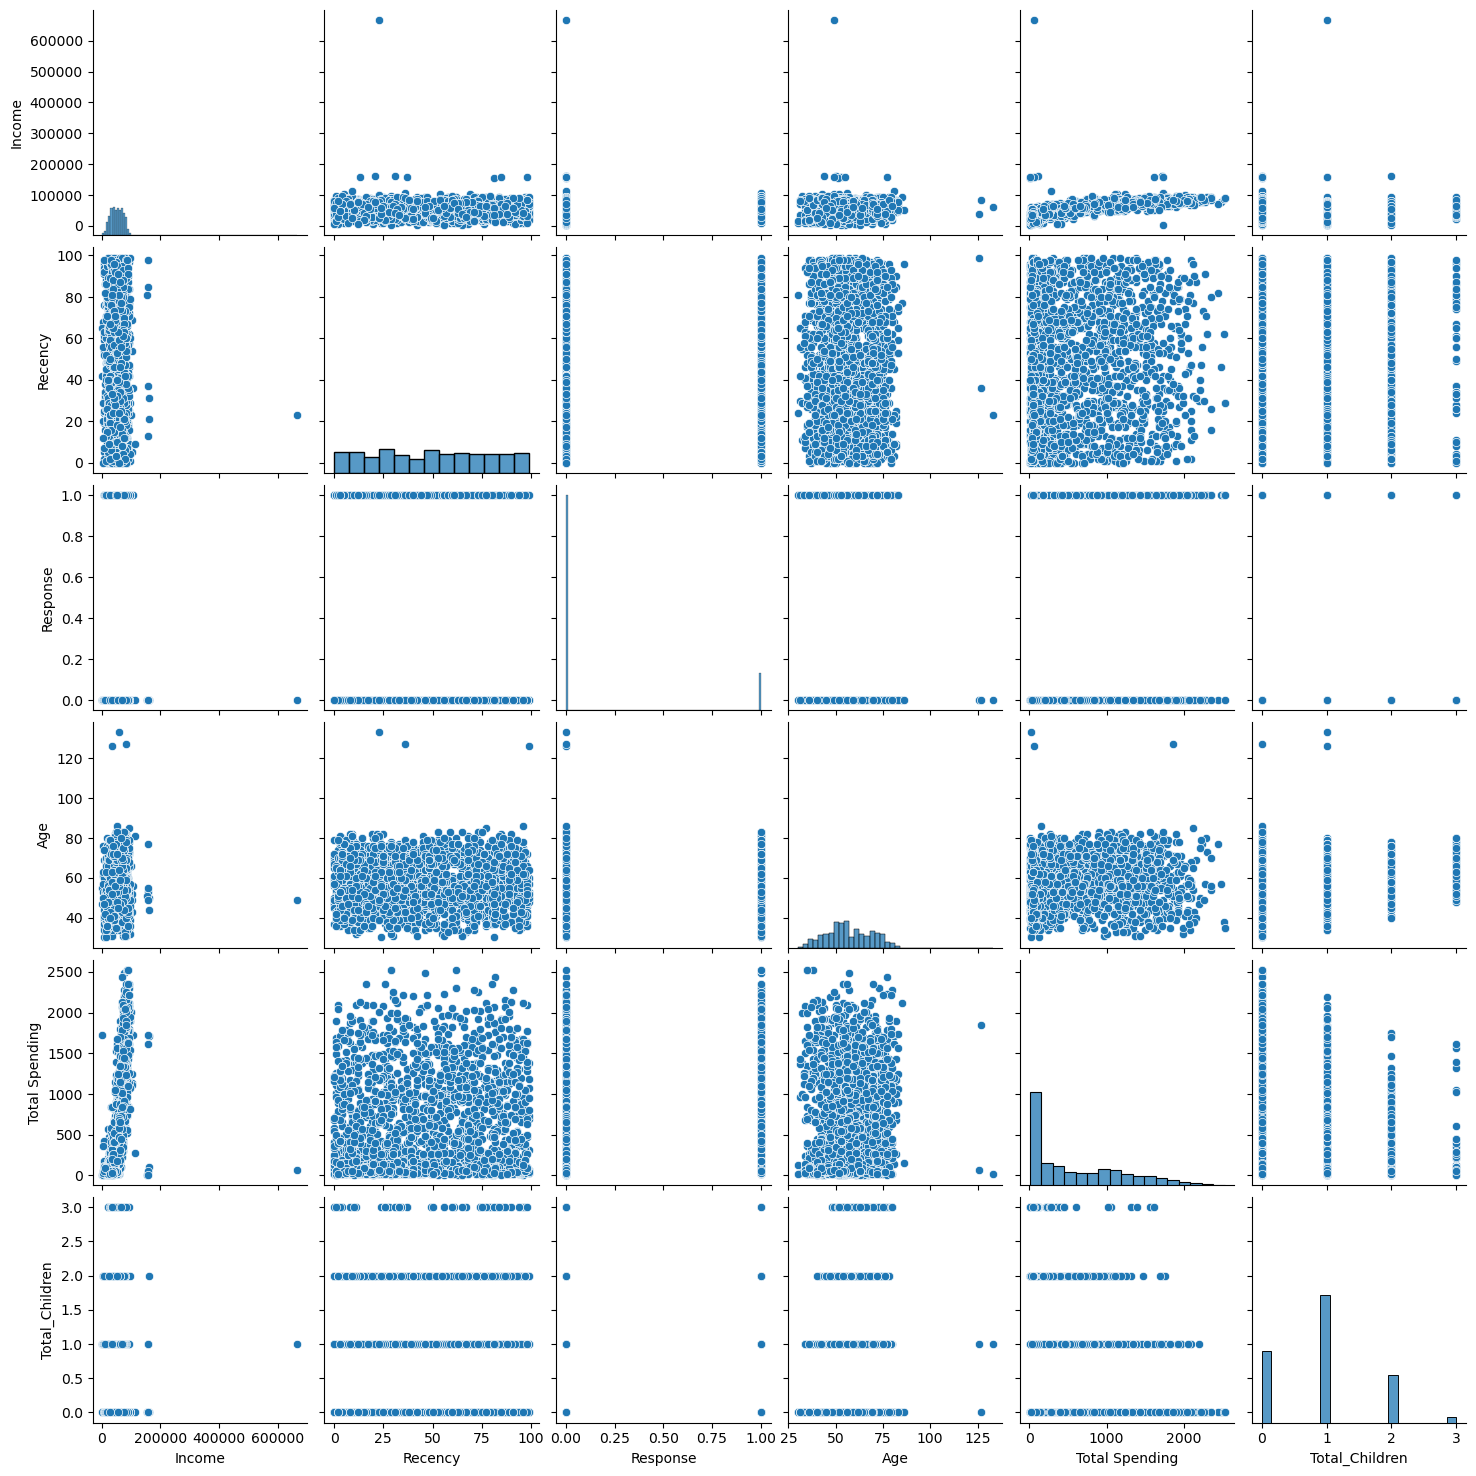

In [11]:
# create a relative pair plots of some features
# pair plot wo plot hota hai jab ha ek features ke 
# saath multiiple feature ke plot create krte hai
cols=["Income","Recency","Response","Age","Total Spending","Total_Children"]
sns.pairplot(df_cleaned[cols])

In [12]:
# Removing Outliers
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600_000)]
df_cleaned.shape

(2236, 15)

# Heatmap

In [13]:
# why heatmap checking corelation between different features
corr=df_cleaned.corr(numeric_only=True)

<Axes: >

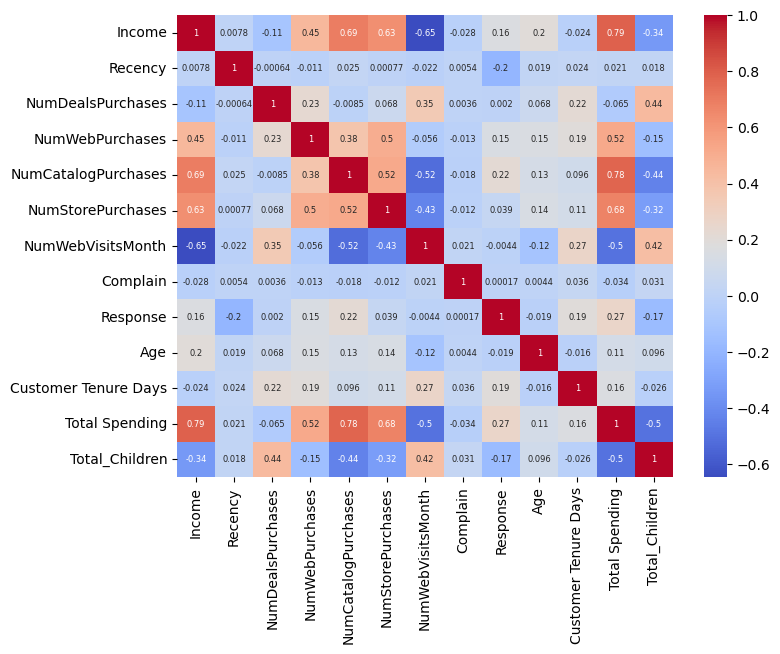

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

# Encoding

In [15]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
cat_cols=["Education","Living_With"]
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])

In [16]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [17]:
df_concat=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

# Scaling

In [18]:
from sklearn.preprocessing import StandardScaler
X=df_concat
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

# Visualize

Text(0.5, 0.92, '3D Projection')

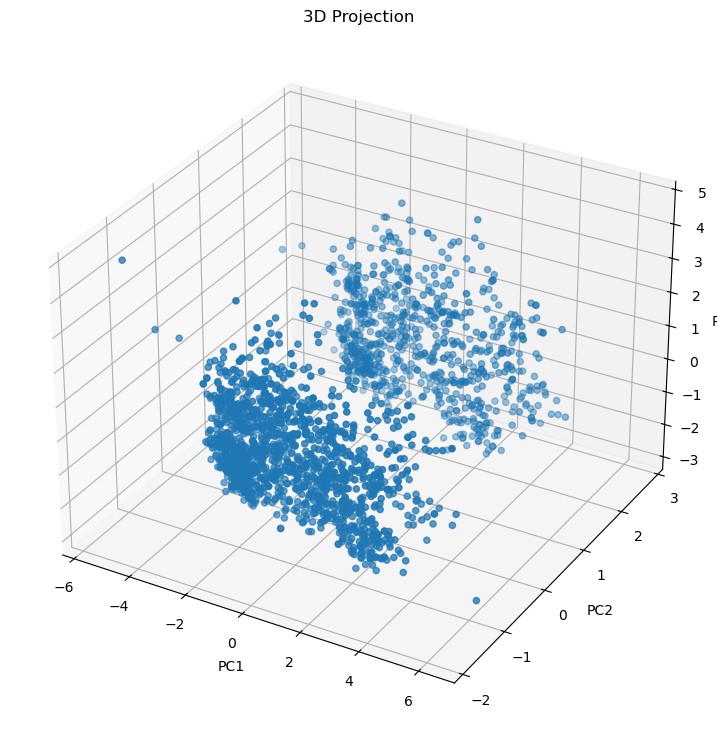

In [37]:
from sklearn.decomposition import PCA #principale component analysis
# we don't have much good result need to decompose it more via decompostion PCA
pca=PCA(n_components=3)
X_pca=pca.fit_transform(X_scaled)

fig=plt.figure(figsize=(9,10))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Projection")

In [29]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

# Analyze K Value

# 1. Elbow Method

In [41]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
import warnings
warnings.filterwarnings("ignore",category=UserWarning)

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

    

In [43]:
knee=KneeLocator(
    range(1,11),wcss,curve="convex",direction="decreasing"
)
optimal_k=knee.elbow

In [45]:
print("Best K is:",optimal_k)

Best K is: 4


Text(0, 0.5, 'wcss')

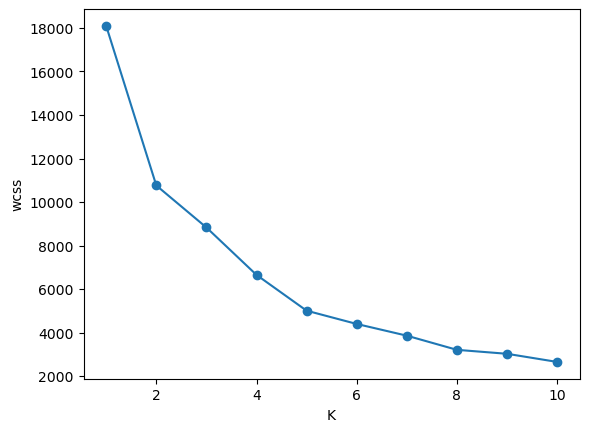

In [47]:
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("K")
plt.ylabel("wcss")

# From silhoutte score

Text(0, 0.5, 'silhouette_score')

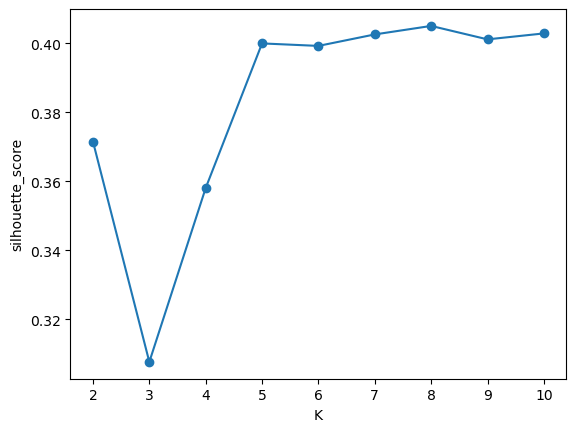

In [55]:
from sklearn.metrics import silhouette_score

score=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    scores=silhouette_score(X_pca,labels)
    score.append(scores)
#plot
plt.plot(range(2,11),score,marker="o")
plt.xlabel("K")
plt.ylabel("silhouette_score")

Text(0, 0.5, 'SS')

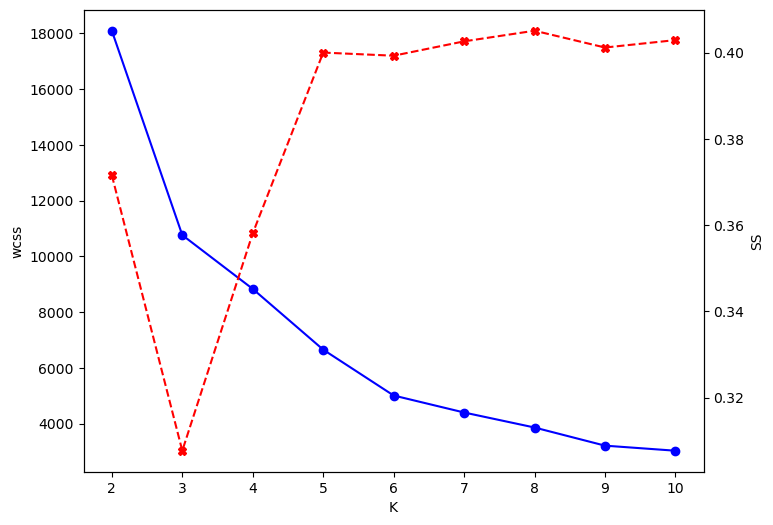

In [60]:
# Combine plot for both the value (silhoutte score VS elbow)
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
plt.xlabel("K")
plt.ylabel("wcss")
ax2=ax1.twinx()
ax2.plot(k_range,score[:len(k_range)],marker="X",color="red",linestyle="--")
ax2.set_ylabel("SS")

# optimal of k where both the grapgh silhouette and wcss intersect

# Clustering

Text(0.5, 0.92, '3D Projection')

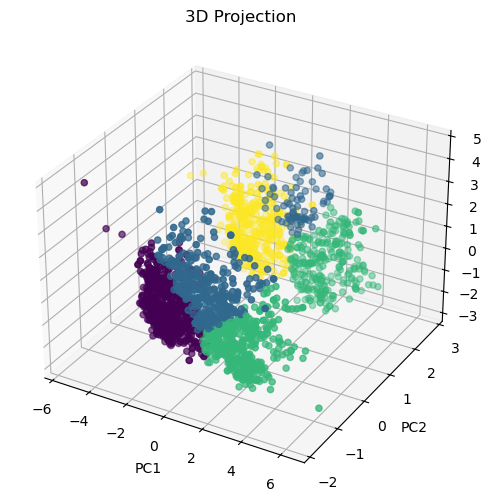

In [66]:
kmeans=KMeans(n_clusters=4,random_state=42)
label=kmeans.fit_predict(X_pca)

fig=plt.figure(figsize=(7,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=label)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Projection")

In [71]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg_clf=AgglomerativeClustering(n_clusters=4,random_state=42)
label=agg_clf.fit_predict(X_pca)

fig=plt.figure(figsize=(7,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=label)

TypeError: AgglomerativeClustering.__init__() got an unexpected keyword argument 'random_state'